In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
df=pd.read_excel(r"D:\data science 2025\git_repository\data-science-project-\project 4(logstic ,Rand for)\credit_card_fraud.xlsx")

In [148]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amount               10000 non-null  float64
 1   transaction_hour     10000 non-null  int64  
 2   merchant_category    10000 non-null  str    
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    10000 non-null  int64  
 7   cardholder_age       10000 non-null  int64  
 8   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 703.3 KB


In [150]:
df.isnull().sum()

amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [151]:
df.duplicated().sum()

np.int64(0)

# EDA

In [152]:
df.describe()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [153]:
df_numm=df.drop('merchant_category', axis=1)
df_numm.corr()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
amount,1.000000,-0.007369,0.004094,0.004232,0.009698,-0.001133,0.012735,0.028404
transaction_hour,-0.007369,1.000000,-0.000255,0.004776,0.004054,-0.003709,0.012198,-0.138665
foreign_transaction,0.004094,-0.000255,1.000000,0.001426,0.012780,-0.007686,0.005408,0.185597
location_mismatch,0.004232,0.004776,0.001426,1.000000,0.002217,-0.005892,0.010049,0.173009
device_trust_score,0.009698,0.004054,0.012780,0.002217,1.000000,-0.000095,0.013717,-0.137913
velocity_last_24h,-0.001133,-0.003709,-0.007686,-0.005892,-0.000095,1.000000,-0.003970,0.103413
cardholder_age,0.012735,0.012198,0.005408,0.010049,0.013717,-0.003970,1.000000,-0.000590
is_fraud,0.028404,-0.138665,0.185597,0.173009,-0.137913,0.103413,-0.000590,1.000000


# visualization

<Axes: >

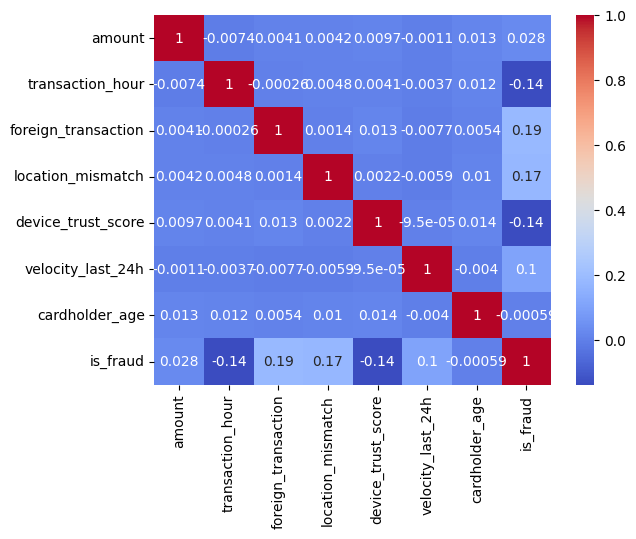

In [154]:
sns.heatmap(df_numm.corr(), annot=True, cmap='coolwarm')

In [155]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


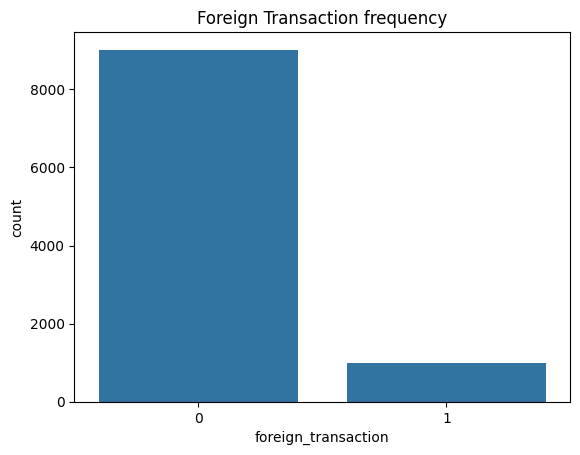

In [156]:
sns.countplot(data=df,x='foreign_transaction')
plt.title('Foreign Transaction frequency')
plt.show()

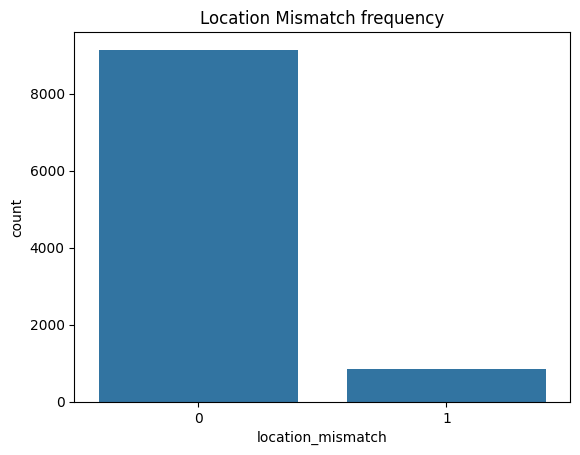

In [157]:
sns.countplot(data=df,x='location_mismatch')
plt.title('Location Mismatch frequency')
plt.show()

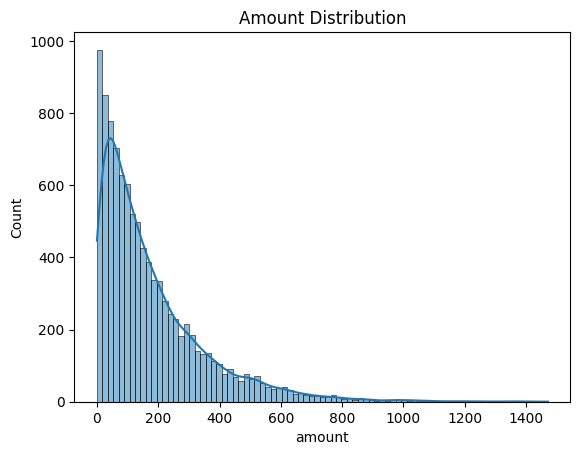

In [158]:
sns.histplot(df['amount'],kde='True')
plt.title('Amount Distribution')
plt.show()

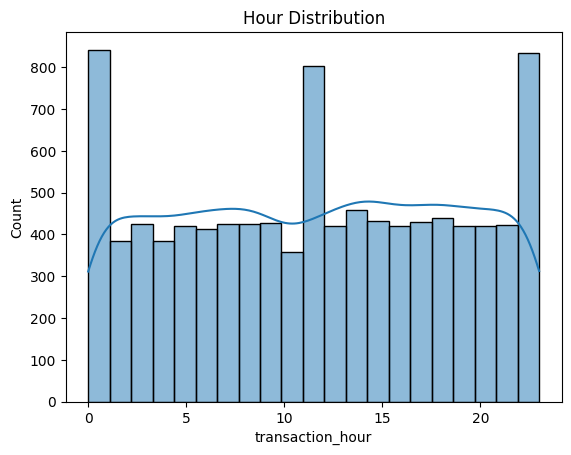

In [159]:
sns.histplot(df['transaction_hour'],kde=True)
plt.title('Hour Distribution')
plt.show()

# machine learning model

In [160]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [161]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [162]:
x=df.iloc[:,[0,1,2,3,4,5,6,7]]
y=df['is_fraud']

In [163]:
le=LabelEncoder()
x['merchant_category_encoded']=le.fit_transform(x['merchant_category'])
x.drop('merchant_category', axis=1, inplace=True)
x.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_encoded
0,84.47,22,0,0,66,3,40,1
1,541.82,3,1,0,87,1,64,4
2,237.01,17,0,0,49,1,61,3
3,164.33,4,0,1,72,3,34,3
4,30.53,15,0,0,79,0,44,2


In [164]:
#standardising independent variables
scaler=StandardScaler()
x_stand=scaler.fit_transform(x)
df_x_comp=pd.DataFrame(x_stand[0:5,0],x.iloc[0:5,0])
df_x_comp.reset_index(inplace=True)
df_x_comp.columns=['x','x_stand']
df_x_comp


,x,x_stand
0,84.47,-0.521597
1,541.82,2.086108
2,237.01,0.348151
3,164.33,-0.066254
4,30.53,-0.829151


# using pickle to save scaler so that we can save mean and std of the data

In [165]:
import pickle
with open('credit_card_scaler.pkl','wb') as f:
     pickle.dump(scaler,f)


In [166]:
x_train, x_test, y_train, y_test = train_test_split(x_stand, y, test_size=0.2, random_state=42)

In [167]:
classifier = LogisticRegression()
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

# using pickle to load the model

In [168]:
import pickle
with open('credit_card_model.pkl', 'wb') as f:
    pickle.dump(classifier,f)

# metrics

In [169]:
coefficients=pd.DataFrame({'feature':df.columns[[0,1,2,3,4,5,6,7]],'coefficient':classifier.coef_[0]})
coefficients

,feature,coefficient
0,amount,0.477250
1,transaction_hour,-2.537692
2,merchant_category,1.311799
3,foreign_transaction,1.247968
4,location_mismatch,-2.827293
5,device_trust_score,1.393254
6,velocity_last_24h,-0.329744
7,cardholder_age,0.226703


In [170]:
#accuracy_score
accuracy_score(y_test,y_pred)

0.99

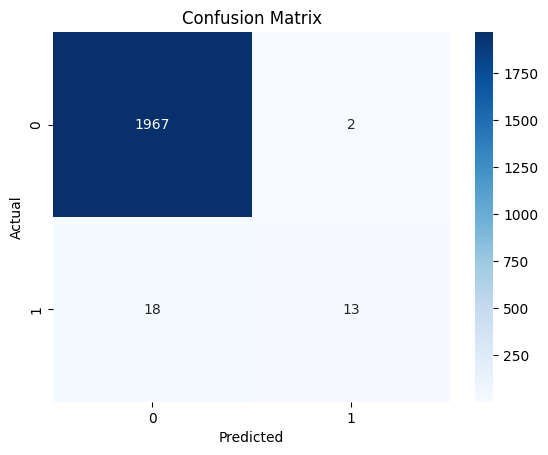

In [171]:
#confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [172]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1969
           1       0.87      0.42      0.57        31

    accuracy                           0.99      2000
   macro avg       0.93      0.71      0.78      2000
weighted avg       0.99      0.99      0.99      2000



# random forest

In [173]:
classifier_rf=RandomForestClassifier(n_estimators=100, random_state=42)
classifier_rf.fit(x_train, y_train)
y_pred_rf=classifier_rf.predict(x_test)

In [174]:
import pickle
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(classifier_rf,f)

# metrics for random forest

In [175]:
#accuracy_score
accuracy_score(y_test,y_pred_rf)

0.993

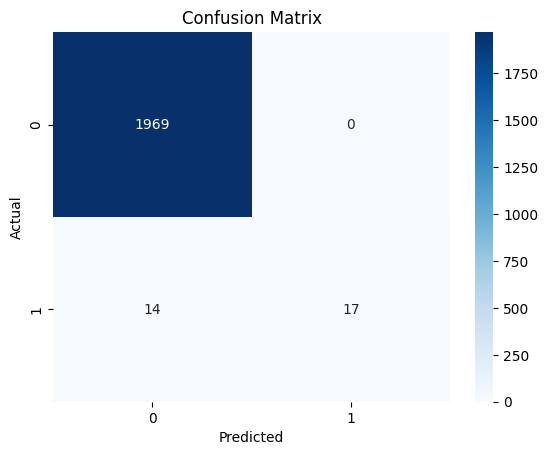

In [176]:
#confusion matrix 
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [177]:
#classification report
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       1.00      0.55      0.71        31

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000



In [178]:
x.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_encoded
0,84.47,22,0,0,66,3,40,1
1,541.82,3,1,0,87,1,64,4
2,237.01,17,0,0,49,1,61,3
3,164.33,4,0,1,72,3,34,3
4,30.53,15,0,0,79,0,44,2


In [179]:
x_sample=[[12,3,1,0,60,3,40,2]]
x_sample_scaled=scaler.transform(x_sample)
y_pred_samp=classifier.predict(x_sample_scaled)
y_pred_samp

d:\data science 2025\git_repository\data-science-project-\project 4(logstic ,Rand for)\demo\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [180]:
x.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_encoded
0,84.47,22,0,0,66,3,40,1
1,541.82,3,1,0,87,1,64,4
2,237.01,17,0,0,49,1,61,3
3,164.33,4,0,1,72,3,34,3
4,30.53,15,0,0,79,0,44,2


In [181]:
x.columns

Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age', 'merchant_category_encoded'],
      dtype='str')